In [ ]:
# ------------------------------------------
# 0. Dependencies Setup & Data Ingestion
# ------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_extraction.text import CountVectorizer
import re

# Load the Titanic Dataset directly via public URL link
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)
print("Initial Dataset Shape:", df.shape)

Initial Dataset Shape: (891, 12)


In [ ]:
# ------------------------------------------
# 1. Data Cleaning
# ------------------------------------------
print("\n--- Task 1: Data Cleaning ---")

# Handle missing values (Median imputation for Age, Mode for Embarked)
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
df.drop(columns=['Cabin'], inplace=True) # Drop due to excessive (>70%) missing data

# Remove duplicate entries
df.drop_duplicates(inplace=True)

# Handle outliers in numerical features using capping (IQR Method)
for col in ['Age', 'Fare']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df[col] = np.clip(df[col], lower_bound, upper_bound)

# Convert data types where necessary
df['PassengerId'] = df['PassengerId'].astype(str)
print("Missing values remaining:\n", df.isnull().sum())


--- Task 1: Data Cleaning ---
Missing values remaining:
 PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


In [ ]:
# ------------------------------------------
# 2. Feature Engineering
# ------------------------------------------
print("\n--- Task 2: Feature Engineering ---")

# Create new feature: FamilySize
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

# Encode categorical variables using Label Encoding
le = LabelEncoder()
df['Sex_Encoded'] = le.fit_transform(df['Sex'])
df['Embarked_Encoded'] = le.fit_transform(df['Embarked'])

# Normalize/Standardize numerical features
scaler = StandardScaler()
numerical_features = ['Age', 'Fare', 'FamilySize']
df[numerical_features] = scaler.fit_transform(df[numerical_features])
print("Sample engineered data features:\n", df[['FamilySize', 'Sex_Encoded', 'Age']].head())


--- Task 2: Feature Engineering ---
Sample engineered data features:
    FamilySize  Sex_Encoded       Age
0    0.059160            1 -0.583432
1    0.059160            0  0.742685
2   -0.560975            0 -0.251903
3    0.059160            0  0.494038
4   -0.560975            1  0.494038



--- Task 3: Principal Component Analysis ---
Variance explained by Component 1: 36.80%
Variance explained by Component 2: 29.47%
Total Retained Variance: 66.26%


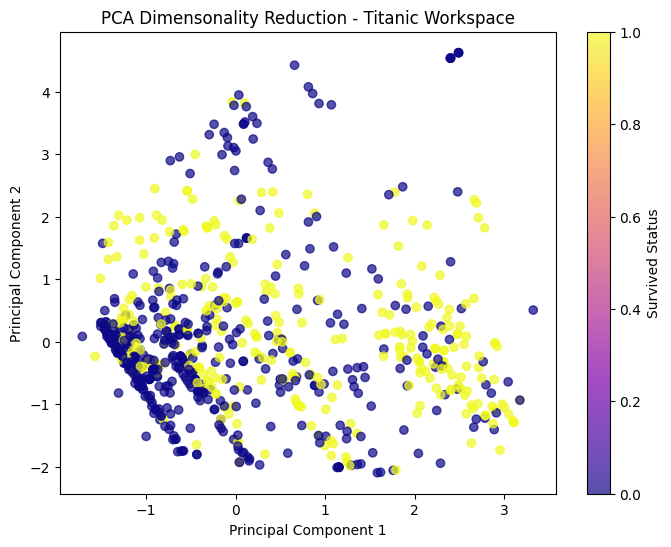

In [ ]:
# ------------------------------------------
# 3. Principal Component Analysis (PCA)
# ------------------------------------------
print("\n--- Task 3: Principal Component Analysis ---")

# Isolate features for dimensionality reduction
pca_features = ['Pclass', 'Age', 'Fare', 'FamilySize', 'Sex_Encoded', 'Embarked_Encoded']
X = df[pca_features]

# Apply PCA for dimensionality reduction
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Explain variance retained
variance_retained = pca.explained_variance_ratio_
print(f"Variance explained by Component 1: {variance_retained[0]*100:.2f}%")
print(f"Variance explained by Component 2: {variance_retained[1]*100:.2f}%")
print(f"Total Retained Variance: {np.sum(variance_retained)*100:.2f}%")

# Visualize results
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df['Survived'], cmap='plasma', alpha=0.7)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA Dimensonality Reduction - Titanic Workspace')
plt.colorbar(label='Survived Status')
plt.show()

In [ ]:
# ------------------------------------------
# 4. Bag of Words (NLP Task)
# ------------------------------------------
print("\n--- Task 4: Bag of Words Implementation ---")

# Clean text data function
def clean_text(text):
    text = re.sub(r'[^a-zA-Z\s]', '', text) # Remove punctuation and symbols
    text = text.lower()                     # Convert text to lower-case
    return text

# Utilize the 'Name' string attribute as our corpus target
df['Clean_Name'] = df['Name'].apply(clean_text)

# Tokenize text and build Bag of Words model
vectorizer = CountVectorizer(max_features=15)
bow_matrix = vectorizer.fit_transform(df['Clean_Name'])

# Display sparse feature matrix slice
feature_names = vectorizer.get_feature_names_out()
bow_df = pd.DataFrame(bow_matrix.toarray(), columns=feature_names)
print("Vocabulary extracted via NLP Tokenization:\n", feature_names)
print("\nSample Slice of Bag of Words Matrix:\n", bow_df.head())



--- Task 4: Bag of Words Implementation ---
Vocabulary extracted via NLP Tokenization:
 ['anna' 'charles' 'edward' 'george' 'henry' 'james' 'john' 'joseph' 'mary'
 'master' 'miss' 'mr' 'mrs' 'thomas' 'william']

Sample Slice of Bag of Words Matrix:
    anna  charles  edward  george  henry  james  john  joseph  mary  master  \
0     0        0       0       0      0      0     0       0     0       0   
1     0        0       0       0      0      0     1       0     0       0   
2     0        0       0       0      0      0     0       0     0       0   
3     0        0       0       0      0      0     0       0     0       0   
4     0        0       0       0      1      0     0       0     0       0   

   miss  mr  mrs  thomas  william  
0     0   1    0       0        0  
1     0   0    1       0        0  
2     1   0    0       0        0  
3     0   0    1       0        0  
4     0   1    0       0        1  


In [ ]:
# ------------------------------------------
# 5. Reinforcement Learning
# ------------------------------------------
print("\n--- Task 5: Reinforcement Learning (Q-learning) ---")

# Setup a simulated text Gridworld route matrix for Titanic lifeboats
# States: Grid indexes 0 to 4 (0=Cabin, 4=Safe Lifeboat)
# Actions: 0=Stay Still, 1=Move Forward
# Rewards: Moving to state 4 gives +100, staying or invalid yields -1

num_states = 5
num_actions = 2
Q_table = np.zeros((num_states, num_actions))

alpha = 0.1   # Learning Rate
gamma = 0.9   # Discount Factor
epsilon = 0.2 # Exploration Parameter
episodes = 200

# Demonstrate learning process algorithm loop
for episode in range(episodes):
    state = 0 # Begin at initial starting position
    while state < 4:
        # Action selection policy (Epsilon-Greedy approach)
        if np.random.uniform(0, 1) < epsilon:
            action = np.random.choice(num_actions)
        else:
            action = np.argmax(Q_table[state, :])

        # Calculate state transition reward mechanics
        if action == 1:
            next_state = state + 1
            reward = 100 if next_state == 4 else -1
        else:
            next_state = state
            reward = -5

        # Standard Bellman Equation update function formula
        Q_table[state, action] = Q_table[state, action] + alpha * (
            reward + gamma * np.max(Q_table[next_state, :]) - Q_table[state, action]
        )
        state = next_state

print("Trained Q-Table Output Matrix:\n", Q_table)
print("\nLearning Complete.")


--- Task 5: Reinforcement Learning (Q-learning) ---
Trained Q-Table Output Matrix:
 [[47.73472326 70.18989368]
 [55.76391645 79.09998465]
 [57.48804529 88.99999853]
 [80.70259184 99.99999993]
 [ 0.          0.        ]]

Learning Complete.
